<a href="https://colab.research.google.com/github/Souhardya-27/My-Project/blob/main/ML_Task/ML_Task_Level_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from datasets import load_dataset

ds = load_dataset("takala/financial_phrasebank","sentences_allagree",revision="refs/pr/10")

print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentences_allagree/train-00000-of-00001.(…):   0%|          | 0.00/169k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2264 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})


In [2]:
from collections import Counter

labels = ds['train']['label']
counts = Counter(labels)
print(counts)

Counter({1: 1391, 2: 570, 0: 303})


**Check the balance**

In [3]:
max_count = max(counts.values())
min_count = min(counts.values())

result = max_count - min_count

if result < 100:
  print("Dataset is balanced")
else:
  print("Dataset is imbalanced")

Dataset is imbalanced


**Train_test_split**

In [4]:
from sklearn.model_selection import train_test_split

df = ds['train'].to_pandas()

X = df['sentence']
y = df['label']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

**TF-IDF**

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

**Logistic Regression**

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_tfidf,y_train)

LogisticRegression()

**Report Precision, Recall, and F1**

In [7]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.54      0.65        56
           1       0.86      0.99      0.92       276
           2       0.85      0.71      0.77       121

    accuracy                           0.86       453
   macro avg       0.85      0.74      0.78       453
weighted avg       0.85      0.86      0.85       453



**Plot confusion metrics**

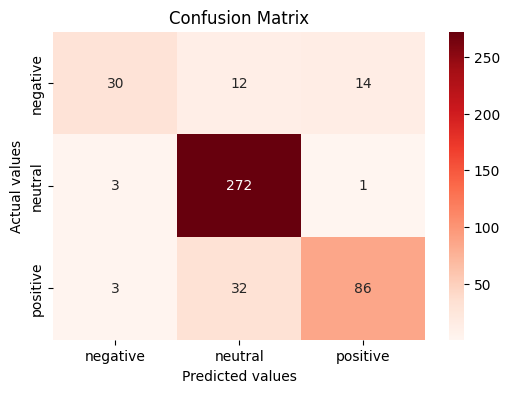

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

conf_met = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(conf_met,annot=True,fmt="d",cmap="Reds",xticklabels=["negative","neutral","positive"],yticklabels=["negative","neutral","positive"])
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.title("Confusion Matrix")
plt.show()